# Data Normalization

In [2]:
import pandas as pd

In [7]:
# paths
in_path  = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_events_0601.csv"
out_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data//mouse_events_0601_norm.csv"

# grid size
GRID_W, GRID_H = 8, 6

# load data
df = pd.read_csv(in_path)

# ensure numeric 
for col in ["x", "y", "page_w", "page_h", "t_ms"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# keep only valid rows
mask = (
    df["x"].notna() & df["y"].notna() &
    df["page_w"].notna() & df["page_h"].notna() &
    (df["page_w"] > 0) & (df["page_h"] > 0)
)
df = df.loc[mask].copy()

# normalization to 8x6 grid 
# x_norm in [0,8], y_norm in [0,6]
df["x_norm"] = df["x"] * GRID_W / df["page_w"]
df["y_norm"] = df["y"] * GRID_H / df["page_h"]

# save
df.to_csv(out_path, index=False)

print("Saved:", out_path)
print(df[["x", "y", "page_w", "page_h", "x_norm", "y_norm"]].head(20))

Saved: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data//mouse_events_0601_norm.csv
      x    y  page_w  page_h    x_norm    y_norm
0     0    0    1440     812  0.000000  0.000000
1     0    0    1440     812  0.000000  0.000000
2     0    0    1440     812  0.000000  0.000000
3     0    0    1440     812  0.000000  0.000000
4     0    0    1440     812  0.000000  0.000000
5     0    0    1440     812  0.000000  0.000000
6     0    0    1440     812  0.000000  0.000000
7     0    0    1440     812  0.000000  0.000000
8     0    0    1440     812  0.000000  0.000000
9     0    0    1440     812  0.000000  0.000000
10    0    0    1440     812  0.000000  0.000000
11    0    0    1440     812  0.000000  0.000000
12    0    0    1440     812  0.000000  0.000000
13    0    0    1440     812  0.000000  0.000000
14    0    0    1440     812  0.000000  0.000000
15  115  256    1440     812  0.638889  1.891626
16  166  264    1440     812

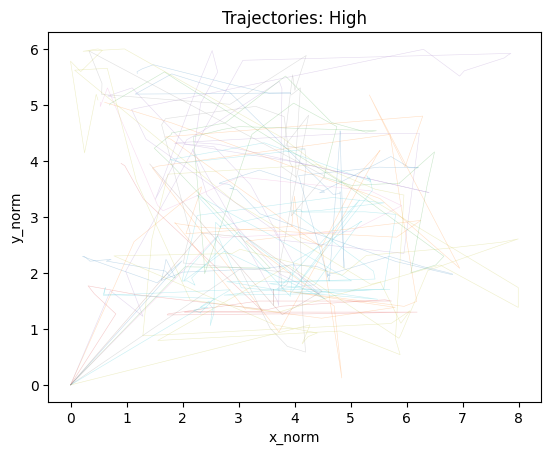

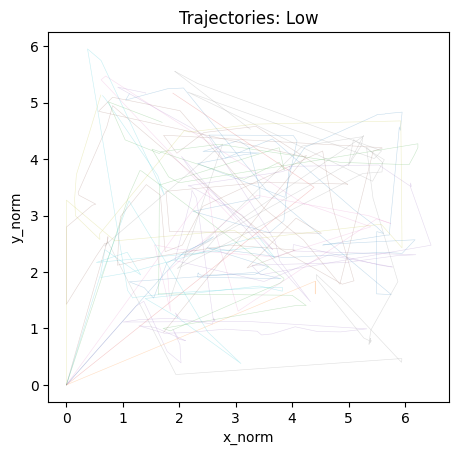

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

events = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_events_0601_norm.csv")
vel    = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Metrics/velocity_metrics_0601_norm.csv")
cond   = pd.read_csv("Data/participants_0601.csv")  # participant_id, interest (Low/High)

events = events.sort_values(["participant_id","t_ms"])
events["dt_s"] = events.groupby("participant_id")["t_ms"].diff() / 1000.0
events["dx"]   = events.groupby("participant_id")["x_norm"].diff()
events["dy"]   = events.groupby("participant_id")["y_norm"].diff()
events["speed"]= np.sqrt(events["dx"]**2 + events["dy"]**2) / np.clip(events["dt_s"], 1e-6, None)

df = events.merge(cond, on="participant_id", how="left") \
           .merge(vel[["participant_id","mean_velocity_norm_s"]], on="participant_id", how="left")
df = df.dropna(subset=["interest"])

# downsample
df = df.groupby("participant_id").nth(list(range(0, 10_000_000, 10))).reset_index()

# sample participants per interest
keep = (df[["participant_id","interest"]].drop_duplicates()
          .groupby("interest").sample(n=10, random_state=1)["participant_id"])
df = df[df["participant_id"].isin(keep)]

for interest, g in df.groupby("interest"):
    plt.figure()
    for pid, p in g.groupby("participant_id"):
        plt.plot(p["x_norm"], p["y_norm"], alpha=0.25, linewidth=0.4)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Trajectories: {interest}")
    plt.xlabel("x_norm"); plt.ylabel("y_norm")
    plt.show()


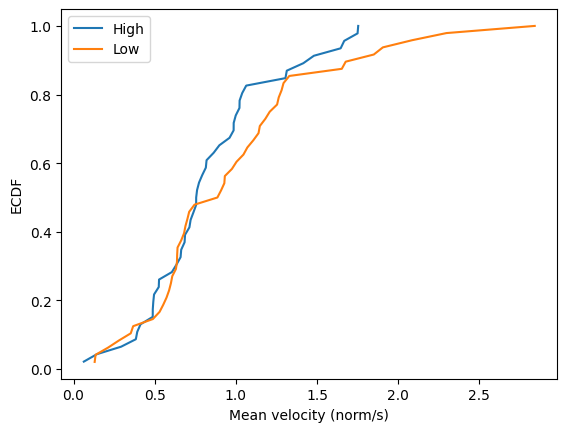

In [5]:
m = vel.merge(cond, on="participant_id", how="left").dropna(subset=["interest"])
for interest, g in m.groupby("interest"):
    x = np.sort(g["mean_velocity_norm_s"].values)
    y = np.arange(1, len(x)+1) / len(x)
    plt.plot(x, y, label=interest)
plt.xlabel("Mean velocity (norm/s)")
plt.ylabel("ECDF")
plt.legend()
plt.show()
